In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson

In [2]:
import re
def extr_url_primer(urlpath):

    data = pd.read_html('https://fbref.com/es/comps/9/2019-2020/horario/Marcadores-y-partidos-de-2019-2020-Premier-League')
    data = data[0]
    for i in range(0,5):
        urlname = '202'+str(i)+'-'+'202'+str(i+1)+'/horario/Marcadores-y-partidos-de-202'+str(i)+'-202'+str(i+1)+'-Premier-League'
        url = urlpath + urlname 

        sesons_data = pd.read_html(url)
        sesons_data = sesons_data[0]
        data = pd.concat([data, sesons_data],axis=0)
    return data

def extraer_numero(cadena):
    numeros = re.findall(r'\b\d+\b', str(cadena))
    if numeros:
        return int(numeros[0])
    else:
        return None

In [3]:
urlpath = 'https://fbref.com/es/comps/9/'
data = extr_url_primer(urlpath)

In [4]:
data = data.dropna(subset='Árbitro')

In [5]:
data[['Goles Local', 'Goles Visitante']] = data['Marcador'].str.split('–', expand=True)
data = data.drop('Marcador', axis=1)
data['Goles Local'] = data['Goles Local'].apply(extraer_numero).fillna(0).astype(int)
data['Goles Visitante'] = data['Goles Visitante'].apply(extraer_numero).fillna(0).astype(int)
data = data.reset_index(drop=True)


In [49]:
data

,Sem.,Día,Fecha,Hora,Local,xG,xG.1,Visitante,Asistencia,Sedes,Árbitro,Informe del partido,Notas,Goles Local,Goles Visitante
0,1.0,Vie,2019-08-09,20:00,Liverpool,1.8,0.9,Norwich City,53333.0,Anfield,Michael Oliver,Informe del partido,NaN,4,1
1,1.0,Sáb,2019-08-10,12:30,West Ham,1.1,3.2,Manchester City,59870.0,London Stadium,Mike Dean,Informe del partido,NaN,0,5
2,1.0,Sáb,2019-08-10,15:00,Burnley,0.9,1.2,Southampton,19784.0,Turf Moor,Graham Scott,Informe del partido,NaN,3,0
3,1.0,Sáb,2019-08-10,15:00,Watford,0.7,0.8,Brighton,20245.0,Vicarage Road Stadium,Craig Pawson,Informe del partido,NaN,0,3
4,1.0,Sáb,2019-08-10,15:00,Crystal Palace,0.9,1.1,Everton,25151.0,Selhurst Park,Jonathan Moss,Informe del partido,NaN,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2094,20.0,Sáb,2025-01-04,15:00,Aston Villa,1.4,0.4,Leicester City,42386.0,Villa Park,Jarred Gillett,Informe del partido,NaN,2,1
2095,20.0,Sáb,2025-01-04,17:30,Brighton,1.5,0.9,Arsenal,31714.0,The American Express Stadium,Anthony Taylor,Informe del partido,NaN,1,1
2096,20.0,Dom,2025-01-05,14:00,Fulham,2.2,1.5,Ipswich Town,27042.0,Craven Cottage,Darren Bond,Informe del partido,NaN,2,2
2097,20.0,Dom,2025-01-05,16:30,Liverpool,2.7,1.0,Manchester Utd,60275.0,Anfield,Michael Oliver,Informe del partido,NaN,2,2


In [6]:
data['Goles Local'] = data['Goles Local'].apply(extraer_numero).fillna(0).astype(int)
data['Goles Visitante'] = data['Goles Visitante'].apply(extraer_numero).fillna(0).astype(int)

In [7]:
data = data.reset_index(drop=True)

In [18]:
data.to_csv('data_prime_league.csv')

In [25]:
data1 = pd.DataFrame({
    'Local':data['Local'],
    'Visitante':data['Visitante'],
    'Goles Local':data['Goles Local'],
    'Goles Visitante':data['Goles Visitante'],

})


# Calcular goles totales anotados y recibidos por cada equipo en casa y como visitante
home_stats = data1.groupby("Local").agg(
    GL=("Goles Local", "sum"), JL=("Local", "count")
).reset_index()

away_stats = data1.groupby("Visitante").agg(
    GV=("Goles Visitante", "sum"), JV=("Visitante", "count")
).reset_index()

home_stats_c = data.groupby("Local").agg(
    GLE=("Goles Visitante","sum"), JL=("Local", "count")
)
away_stats_c = data.groupby("Visitante").agg(
    GVE=("Goles Local","sum"), JV=("Visitante", "count")
)



# Calcular el promedio de goles anotados por partido
#home_stats_c["PGLE"] = home_stats_c["GLE"] / (home_stats["JL"])
#away_stats_c["PGVE"] = away_stats_c["GVE"] / (away_stats["JV"])
home_stats["PGL"] = home_stats["GL"] / (home_stats["JL"])
away_stats["PGV"] = away_stats["GV"] / (away_stats["JV"])
home_stats_c["PGLE"] = home_stats_c["GLE"] / home_stats_c["JL"] 
away_stats_c["PGVE"] = away_stats_c["GVE"] / away_stats_c["JV"] 

# Calcular los goles recibidos por cada equipo
home_conceded = data1.groupby("Local").agg(GEL=("Goles Visitante", "sum"))
away_conceded = data1.groupby("Visitante").agg(GEV=("Goles Local", "sum"))


# Combinar datos de promedio de goles anotados y recibidos

team_stats = home_stats.merge(home_conceded, on="Local").merge(
    away_stats.merge(away_conceded, on="Visitante"), left_on="Local", right_on="Visitante"
).merge(home_stats_c["PGLE"], on="Local").merge(away_stats_c["PGVE"], on="Visitante")

overall_avg_home_goals = home_stats["PGL"].mean()
 
# Renombrar columnas para claridad
team_stats = team_stats.rename(columns={"Local": "Team"}).drop(columns="Visitante")
team_stats['#PJ'] = home_stats["JL"] + away_stats["JV"]
team_stats['IAL'] = home_stats["PGL"] / overall_avg_home_goals

# Mostrar la tabla final
team_stats




,Team,GL,JL,PGL,GEL,GV,JV,PGV,GEV,PGLE,PGVE,#PJ,IAL
0,Arsenal,214,104,2.057692,109,176,106,1.660377,116,1.048077,1.094340,210,1.424525
1,Aston Villa,180,106,1.698113,148,125,104,1.201923,158,1.396226,1.519231,210,1.175591
2,Bournemouth,81,67,1.208955,93,82,68,1.205882,135,1.388060,1.985294,135,0.836951
3,Brentford,115,68,1.691176,94,87,67,1.298507,110,1.382353,1.641791,135,1.170789
4,Brighton,142,105,1.352381,133,136,105,1.295238,155,1.266667,1.476190,210,0.936244
5,Burnley,75,76,0.986842,118,76,76,1.000000,118,1.552632,1.552632,152,0.683184
6,Chelsea,179,105,1.704762,114,180,106,1.698113,145,1.085714,1.367925,211,1.180194
7,Crystal Palace,130,106,1.226415,135,110,104,1.057692,162,1.273585,1.557692,210,0.849038
8,Everton,122,104,1.173077,129,101,105,0.961905,174,1.240385,1.657143,209,0.812113
9,Fulham,89,68,1.308824,98,80,67,1.194030,99,1.441176,1.477612,135,0.906089


In [33]:
# Crear DataFrames base con estadísticas locales y visitantes
home_stats = data1.groupby("Local").agg(
    GL=("Goles Local", "sum"), JL=("Local", "count"), GLE=("Goles Visitante", "sum")
).reset_index()

away_stats = data1.groupby("Visitante").agg(
    GV=("Goles Visitante", "sum"), JV=("Visitante", "count"), GVE=("Goles Local", "sum")
).reset_index()

# Calcular promedios
home_stats["PGL"] = home_stats["GL"] / home_stats["JL"]  # Promedio goles local
home_stats["PGLE"] = home_stats["GLE"] / home_stats["JL"]  # Promedio goles en contra local

away_stats["PGV"] = away_stats["GV"] / away_stats["JV"]  # Promedio goles visitante
away_stats["PGVE"] = away_stats["GVE"] / away_stats["JV"]  # Promedio goles en contra visitante

# Calcular promedio general de goles locales
overall_avg_home_goals = home_stats["PGL"].mean()
overall_avg_home_goals_c = home_stats["PGLE"].mean()
overall_avg_away_goals = away_stats["PGV"].mean()
overall_avg_away_goals_c = away_stats["PGVE"].mean()

# Combinar las estadísticas locales y visitantes
team_stats = pd.merge(
    home_stats, away_stats, left_on="Local", right_on="Visitante", suffixes=("_Home", "_Away")
)

# Agregar columnas calculadas
team_stats = team_stats.rename(columns={"Local": "Team"}).drop(columns=["Visitante"])
team_stats["#PJ"] = team_stats["JL"] + team_stats["JV"]
team_stats["IAL"] = team_stats["PGL"] / overall_avg_home_goals
team_stats["IDL"] = team_stats["PGLE"] / overall_avg_home_goals_c
team_stats["IAV"] = team_stats["PGV"] / overall_avg_away_goals
team_stats["IDV"] = team_stats["PGVE"] / overall_avg_away_goals_c

# Organizar las columnas finales para que sean más legibles
team_stats = team_stats[
    [
        "Team","#PJ", "JL","JV",       # Equipo
        "GL", "GLE","GV", "GVE", # Goles Favor Encontra
        "PGL","PGLE", "PGV", "PGVE",  # promedios
        "IAL","IDL","IAV","IDV",    # Métricas adicionales
    ]
]

# Mostrar la tabla final
team_stats


,Team,#PJ,JL,JV,GL,GLE,GV,GVE,PGL,PGLE,PGV,PGVE,IAL,IDL,IAV,IDV
0,Arsenal,210,104,106,214,109,176,116,2.057692,1.048077,1.660377,1.094340,1.424525,0.733681,1.322097,0.659792
1,Aston Villa,210,106,104,180,148,125,158,1.698113,1.396226,1.201923,1.519231,1.175591,0.977395,0.957047,0.915964
2,Bournemouth,135,67,68,81,93,82,135,1.208955,1.388060,1.205882,1.985294,0.836951,0.971678,0.960200,1.196959
3,Brentford,135,68,67,115,94,87,110,1.691176,1.382353,1.298507,1.641791,1.170789,0.967683,1.033954,0.989857
4,Brighton,210,105,105,142,133,136,155,1.352381,1.266667,1.295238,1.476190,0.936244,0.886700,1.031350,0.890014
5,Burnley,152,76,76,75,118,76,118,0.986842,1.552632,1.000000,1.552632,0.683184,1.086883,0.796263,0.936102
6,Chelsea,211,105,106,179,114,180,145,1.704762,1.085714,1.698113,1.367925,1.180194,0.760029,1.352145,0.824739
7,Crystal Palace,210,106,104,130,135,110,162,1.226415,1.273585,1.057692,1.557692,0.849038,0.891543,0.842201,0.939153
8,Everton,209,104,105,122,129,101,174,1.173077,1.240385,0.961905,1.657143,0.812113,0.868302,0.765929,0.999113
9,Fulham,135,68,67,89,98,80,99,1.308824,1.441176,1.194030,1.477612,0.906089,1.008861,0.950762,0.890871


In [48]:
#Local Visitante
#IAL*IDL*promedio de goles
#IAV*IDL*promedio de goles

mul = team_stats['IAL'][0]*team_stats['IDL'][1]*team_stats['GL'].mean()
muv = team_stats['IAV'][1]*team_stats['IDL'][0]*team_stats['GV'].mean()

# tabla = [[float(poisson.pmf(i, mul)*poisson.pmf(j, muv)) for i in range(0,6) ],
#          [float(poisson.pmf(i, mul)*poisson.pmf(1, muv)) for i in range(0,6)],
#          [float(poisson.pmf(i, mul)*poisson.pmf(2, muv)) for i in range(0,6)],
#          [float(poisson.pmf(i, mul)*poisson.pmf(3, muv)) for i in range(0,6)],
#          [float(poisson.pmf(i, mul)*poisson.pmf(4, muv)) for i in range(0,6)],
#          [float(poisson.pmf(i, mul)*poisson.pmf(5, muv)) for i in range(0,6)],
#          ]

tabla = [[float(poisson.pmf(i, mul) * poisson.pmf(j, muv)) for i in range(6)] for j in range(6)]

tabla

[[1.1925391256697533e-105,
  2.0164649735156697e-103,
  1.7048207903165963e-101,
  9.608940944569129e-100,
  4.061940700776202e-98,
  1.3736674917081495e-96],
 [8.64654101168434e-104,
  1.4620440299882092e-101,
  1.2360854720607875e-99,
  6.966991704310596e-98,
  2.9451223947529776e-96,
  9.959817709797532e-95],
 [3.1346003605856926e-102,
  5.300297237242213e-100,
  4.481137556857207e-98,
  2.5257192071393824e-96,
  1.0676849514836613e-94,
  3.610697982269498e-93],
 [7.575838251239244e-101,
  1.2809988494142368e-98,
  1.0830207811869334e-96,
  6.104267842858591e-95,
  2.5804273480690535e-93,
  8.726491654788995e-92],
 [1.3732211113081622e-99,
  2.3219802287744798e-97,
  1.963118735366448e-95,
  1.1064794670770268e-93,
  4.6773666399038015e-92,
  1.5817922942125276e-90],
 [1.9913162430403896e-98,
  3.3671175803381917e-96,
  2.8467303572314957e-94,
  1.604512570653822e-92,
  6.782677667854121e-91,
  2.2937665774602827e-89]]

In [50]:
tabla[0].sum()+tabla[1].sum()+tabla[2].sum()+tabla[3].sum()+tabla[4].sum()+tabla[5].sum()+tabla[6].sum()


AttributeError: 'list' object has no attribute 'sum'

In [41]:
print(team_stats['GL'].sum())
print(team_stats['GV'].sum())

3279
2788


In [12]:
data3 = [data,data2]
data3 = pd.concat(data3)

In [13]:
data3 = data3.drop('Notas',axis=1)

In [14]:
data3 = data3.reset_index(drop=True)

In [15]:
#para quitar los valores nan de una fila o si es cero son las filas que estaban vacias
condition = (data3.isna().any(axis=1))&((data3 == 0).any(axis=1))
data3 = data3[~condition]

In [58]:
data3=data3.reset_index(drop=True)

In [16]:
data3['Goles Totales'] = data3['Goles Local'] + data3['Goles Visitante']
data4 = data3.groupby('Sem.')['Goles Totales'].sum()

In [92]:
data5 = pd.DataFrame(data4)

<BarContainer object of 38 artists>

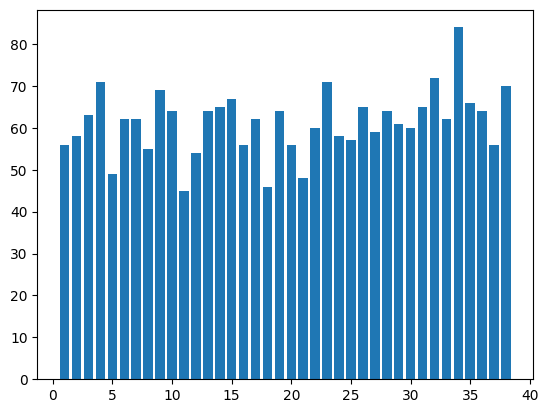

In [105]:
plt.bar(np.arange(1,39,1),data5['Goles Totales'])

In [107]:
data['Goles Totales'] = data['Goles Local'] + data['Goles Visitante']
data6 = data.groupby('Sem.')['Goles Totales'].sum()

<BarContainer object of 38 artists>

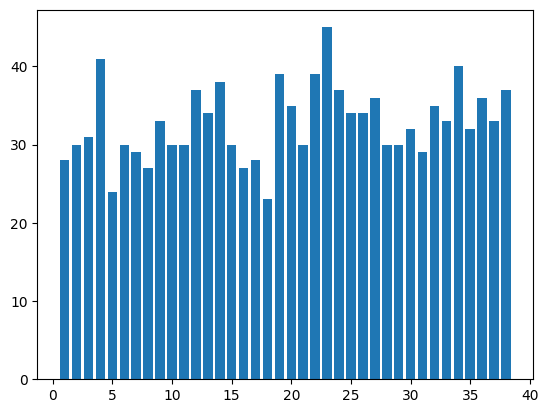

In [110]:
data6 = pd.DataFrame(data6)
plt.bar(np.arange(1,39,1),data6['Goles Totales'])

In [111]:
data6

,Goles Totales
Sem.,
1.0,28
2.0,30
3.0,31
4.0,41
5.0,24
6.0,30
7.0,29
8.0,27
9.0,33


In [117]:
print(data[(data['Sem.']==1.0)]['Goles Totales'].sum()/len(data[(data['Sem.']==1.0)]))

2.8


In [120]:
data7 = pd.read_html("https://fbref.com/es/comps/9/2021-2022/horario/Marcadores-y-partidos-de-2022-2023-Premier-League")

In [122]:
data7 = data7[0]

In [123]:
data7[['Goles Local', 'Goles Visitante']] = data7['Marcador'].str.split('–', expand=True)

In [124]:
data7['Goles Local'] = data7['Goles Local'].apply(extraer_numero).fillna(0).astype(int)
data7['Goles Visitante'] = data7['Goles Visitante'].apply(extraer_numero).fillna(0).astype(int)

In [125]:
data7 = data7.drop('Notas',axis=1)

In [133]:
data7['Goles Totales'] = data7['Goles Local'] + data7['Goles Visitante']

In [134]:
data8 = [data3,data7]
data8 = pd.concat(data8)

In [135]:
data8=data8.reset_index(drop=True)

In [136]:
data8=data8.drop('Marcador',axis=1)

In [66]:
data8[:20]

NameError: name 'data8' is not defined

<BarContainer object of 1208 artists>

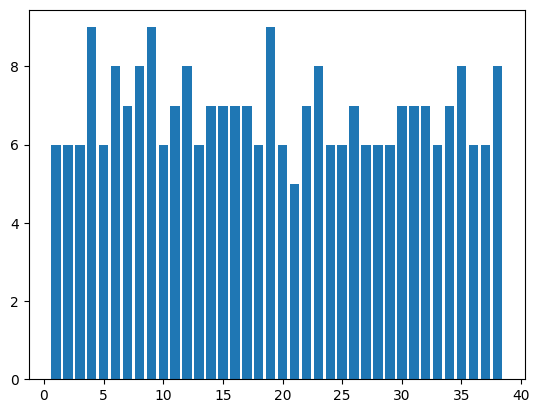

In [138]:
plt.bar(data8['Sem.'],data8['Goles Totales'])

<BarContainer object of 1208 artists>

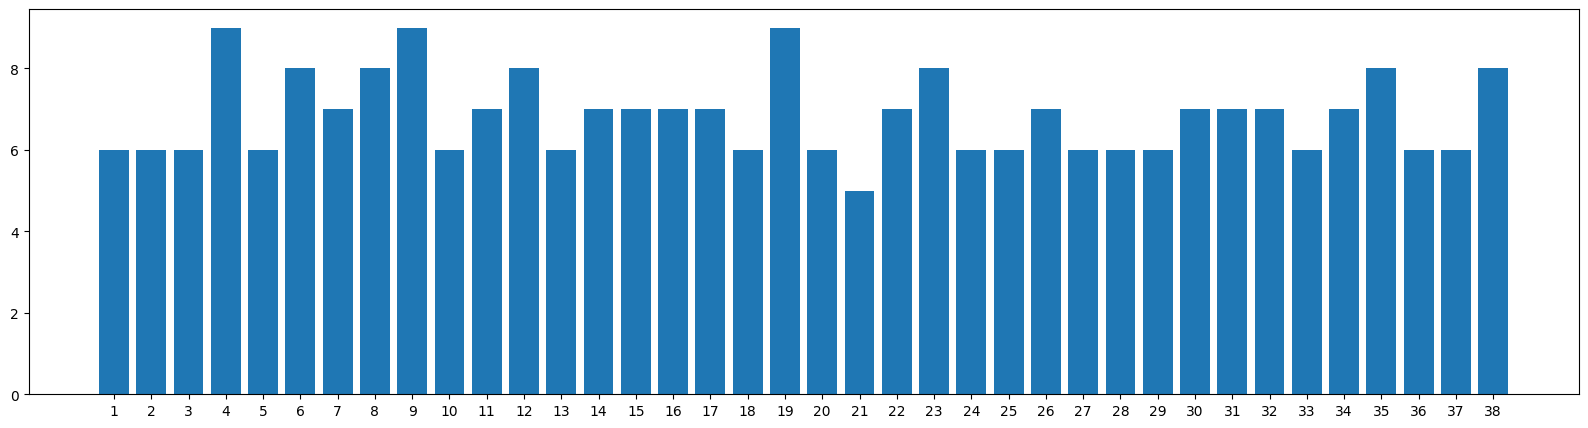

In [155]:
fig, ax = plt.subplots(figsize=(20,5))
ax.set_xticks(np.arange(1,39),labels=np.arange(1,39))
ax.bar(data8['Sem.'],data8['Goles Totales'])

In [166]:
data8[data8['Sem.']==1.0]

,Sem.,Día,Fecha,Hora,Local,xG,xG.1,Visitante,Asistencia,Sedes,Árbitro,Informe del partido,Goles Local,Goles Visitante,Goles Totales
0,1.0,Vie,2023-08-11,20:00,Burnley,0.3,1.9,Manchester City,21572.0,Turf Moor,Craig Pawson,Informe del partido,0,3,3
1,1.0,Sáb,2023-08-12,12:30,Arsenal,0.8,1.2,Nott'ham Forest,59984.0,Emirates Stadium,Michael Oliver,Informe del partido,2,1,3
2,1.0,Sáb,2023-08-12,15:00,Everton,2.7,1.5,Fulham,39940.0,Goodison Park,Stuart Attwell,Informe del partido,0,1,1
3,1.0,Sáb,2023-08-12,15:00,Sheffield Utd,0.5,1.9,Crystal Palace,31194.0,Bramall Lane,John Brooks,Informe del partido,0,1,1
4,1.0,Sáb,2023-08-12,15:00,Brighton,4.0,1.5,Luton Town,31872.0,The American Express Community Stadium,David Coote,Informe del partido,4,1,5
5,1.0,Sáb,2023-08-12,15:00,Bournemouth,1.3,1.1,West Ham,11245.0,Vitality Stadium,Peter Bankes,Informe del partido,1,1,2
6,1.0,Sáb,2023-08-12,17:30,Newcastle Utd,3.3,1.8,Aston Villa,52207.0,St James' Park,Andy Madley,Informe del partido,5,1,6
7,1.0,Dom,2023-08-13,14:00,Brentford,2.2,1.3,Tottenham,17066.0,Gtech Community Stadium,Robert Jones,Informe del partido,2,2,4
8,1.0,Dom,2023-08-13,16:30,Chelsea,1.4,1.3,Liverpool,40096.0,Stamford Bridge,Anthony Taylor,Informe del partido,1,1,2
9,1.0,Lun,2023-08-14,20:00,Manchester Utd,2.2,2.2,Wolves,73358.0,Old Trafford,Simon Hooper,Informe del partido,1,0,1


In [172]:
data9 = {
    'Sem 1':data8[data8['Sem.']==1.0]['Goles Totales'],
    'Sem 2':data8[data8['Sem.']==2.0]['Goles Totales'],
    'Sem 3':data8[data8['Sem.']==3.0]['Goles Totales'],
    'Sem 4':data8[data8['Sem.']==4.0]['Goles Totales'],
    'Sem 5':data8[data8['Sem.']==5.0]['Goles Totales'],
    'Sem 6':data8[data8['Sem.']==6.0]['Goles Totales'],
    'Sem 7':data8[data8['Sem.']==7.0]['Goles Totales'],
    'Sem 8':data8[data8['Sem.']==8.0]['Goles Totales'],
    'Sem 9':data8[data8['Sem.']==9.0]['Goles Totales'],
    'Sem 10':data8[data8['Sem.']==10.0]['Goles Totales'],
    'Sem 11':data8[data8['Sem.']==11.0]['Goles Totales'],
    'Sem 12':data8[data8['Sem.']==12.0]['Goles Totales'],
}

,Sem 1,Sem 2,Sem 3,Sem 4,Sem 5,Sem 6,Sem 7,Sem 8,Sem 9,Sem 10,Sem 11,Sem 12
0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
886,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.0
887,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.0
888,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0
889,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0


<BarContainer object of 30 artists>

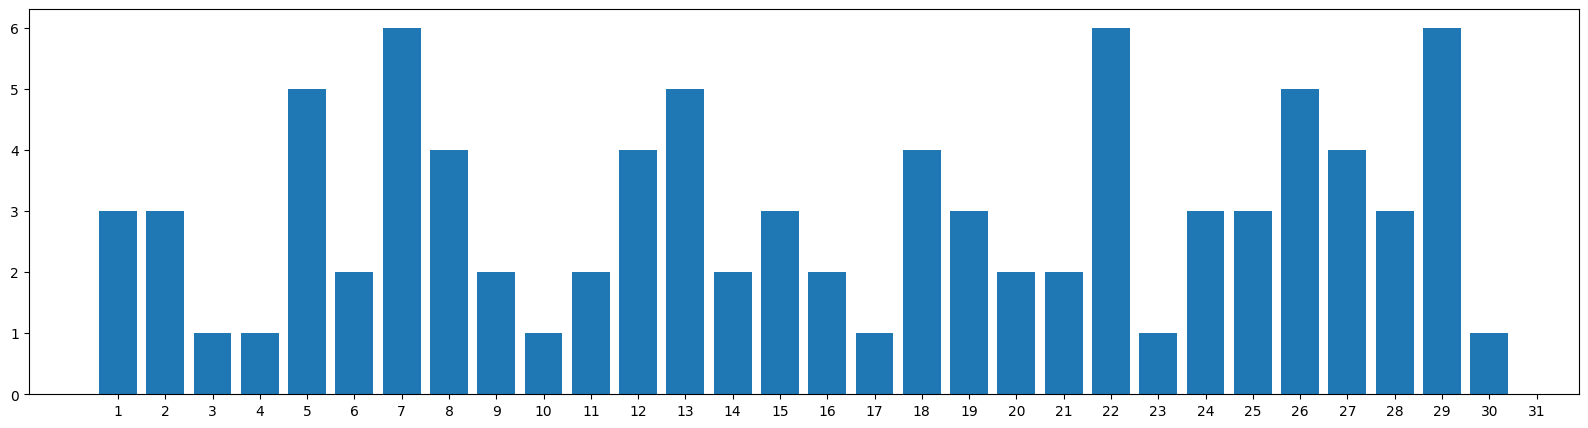

In [189]:
fig, ax = plt.subplots(figsize=(20,5))
ax.set_xticks(np.arange(0,38),labels=np.arange(1,39))
ax.bar(np.arange(0,30),data9['Sem 1'])

In [186]:
data9['Sem 1'].reset_index(drop=True)

0     3
1     3
2     1
3     1
4     5
5     2
6     6
7     4
8     2
9     1
10    2
11    4
12    5
13    2
14    3
15    2
16    1
17    4
18    3
19    2
20    2
21    6
22    1
23    3
24    3
25    5
26    4
27    3
28    6
29    1
Name: Goles Totales, dtype: int64

In [196]:
data8[(data8['Local'].str.contains('Leicester', case=False, na=False)) & (data8['Visitante'].str.contains('Manchester City'))]

,Sem.,Día,Fecha,Hora,Local,xG,xG.1,Visitante,Asistencia,Sedes,Árbitro,Informe del partido,Goles Local,Goles Visitante,Goles Totales
496,14.0,Sáb,2022-10-29,12:30,Leicester City,0.7,1.0,Manchester City,32223.0,King Power Stadium,Robert Jones,Informe del partido,0,1,1
798,4.0,Sáb,2021-09-11,15:00,Leicester City,0.6,2.8,Manchester City,32087.0,King Power Stadium,Paul Tierney,Informe del partido,0,1,1


In [221]:
def filtro(local,visitante):
    data=data8[(data8['Local'].str.contains(local, case=False, na=False)) & (data8['Visitante'].str.contains(visitante))]#filtro para los equipos
    data.loc[:, 'Fecha'] = pd.to_datetime(data['Fecha']).dt.date #se convierte a fecha el .loc es para no copias una columna
    data_sorted=data.sort_values(by='Fecha', ascending=True) #ordena por fecha de forma ascendente
    return data_sorted

In [222]:
filtro('Fulham','Bou')

,Sem.,Día,Fecha,Hora,Local,xG,xG.1,Visitante,Asistencia,Sedes,Árbitro,Informe del partido,Goles Local,Goles Visitante,Goles Totales
469,11.0,Sáb,2022-10-15,15:00,Fulham,2.1,1.0,Bournemouth,22541.0,Craven Cottage,Graham Scott,Informe del partido,2,2,4
232,24.0,Sáb,2024-02-10,15:00,Fulham,1.6,1.8,Bournemouth,24271.0,Craven Cottage,Darren England,Informe del partido,3,1,4


In [223]:
filtro('Tott','Wol')

,Sem.,Día,Fecha,Hora,Local,xG,xG.1,Visitante,Asistencia,Sedes,Árbitro,Informe del partido,Goles Local,Goles Visitante,Goles Totales
1019,25.0,Dom,2022-02-13,14:00,Tottenham,1.2,1.3,Wolves,56452.0,Tottenham Hotspur Stadium,Kevin Friend,Informe del partido,0,2,2
400,3.0,Sáb,2022-08-20,12:30,Tottenham,1.7,0.7,Wolves,61298.0,Tottenham Hotspur Stadium,Simon Hooper,Informe del partido,1,0,1
240,25.0,Sáb,2024-02-17,15:00,Tottenham,1.6,1.8,Wolves,61532.0,Tottenham Hotspur Stadium,Anthony Taylor,Informe del partido,1,2,3


In [224]:
filtro('Crys','Sout')

,Sem.,Día,Fecha,Hora,Local,xG,xG.1,Visitante,Asistencia,Sedes,Árbitro,Informe del partido,Goles Local,Goles Visitante,Goles Totales
937,17.0,Mié,2021-12-15,19:30,Crystal Palace,1.2,0.6,Southampton,22861.0,Selhurst Park,Simon Hooper,Informe del partido,2,2,4
498,14.0,Sáb,2022-10-29,15:00,Crystal Palace,0.9,1.3,Southampton,25130.0,Selhurst Park,Michael Salisbury,Informe del partido,1,0,1


<BarContainer object of 100 artists>

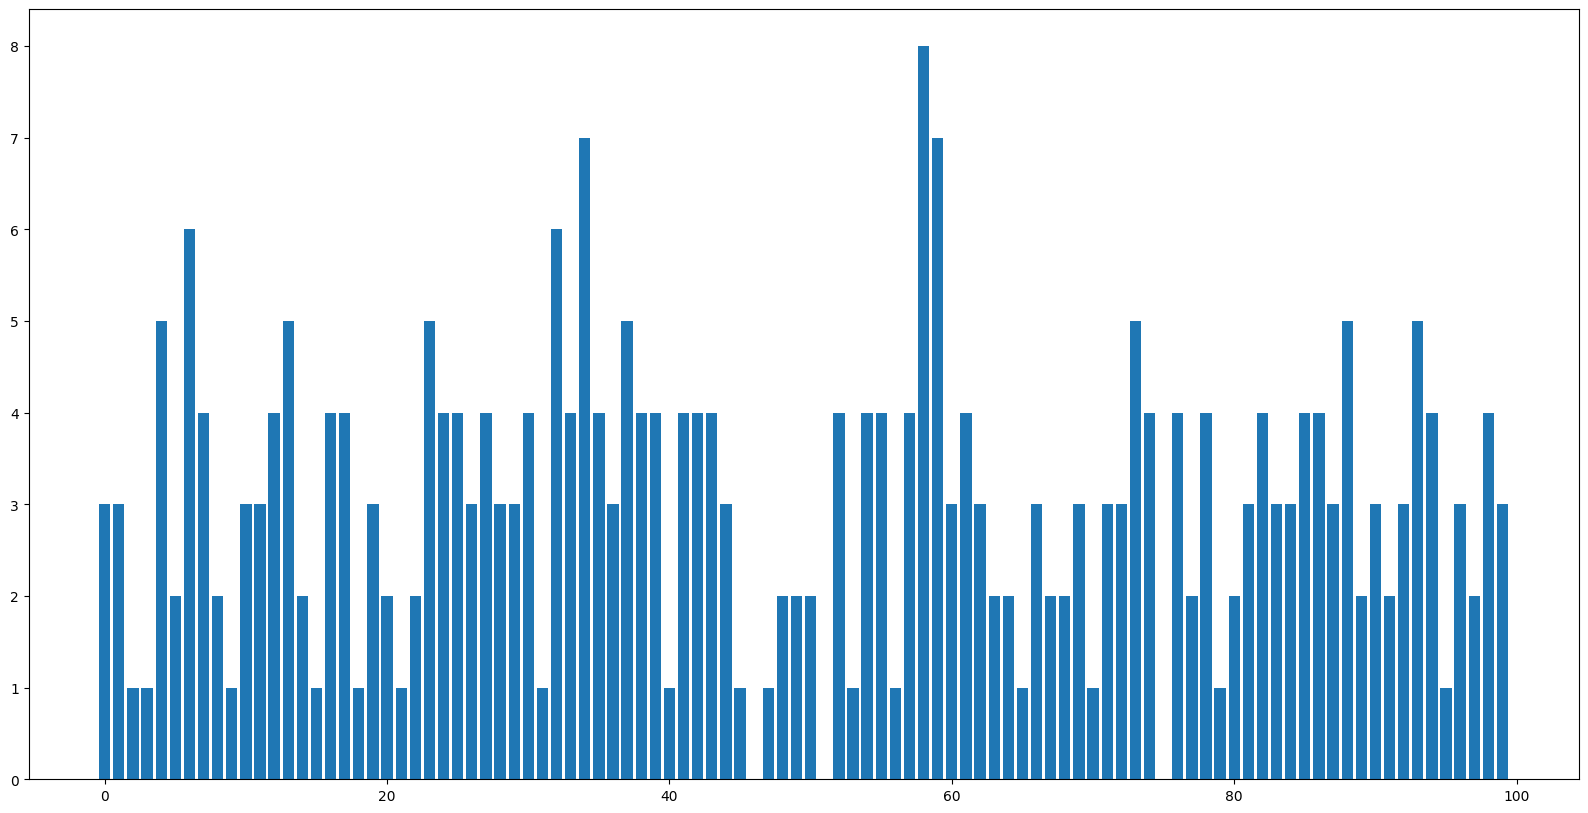

In [34]:
fig, ax = plt.subplots(figsize=(20,10))
ax.bar(np.arange(0,100),data3['Goles Totales'][:100])

In [46]:
goles = data3['Goles Totales'].values

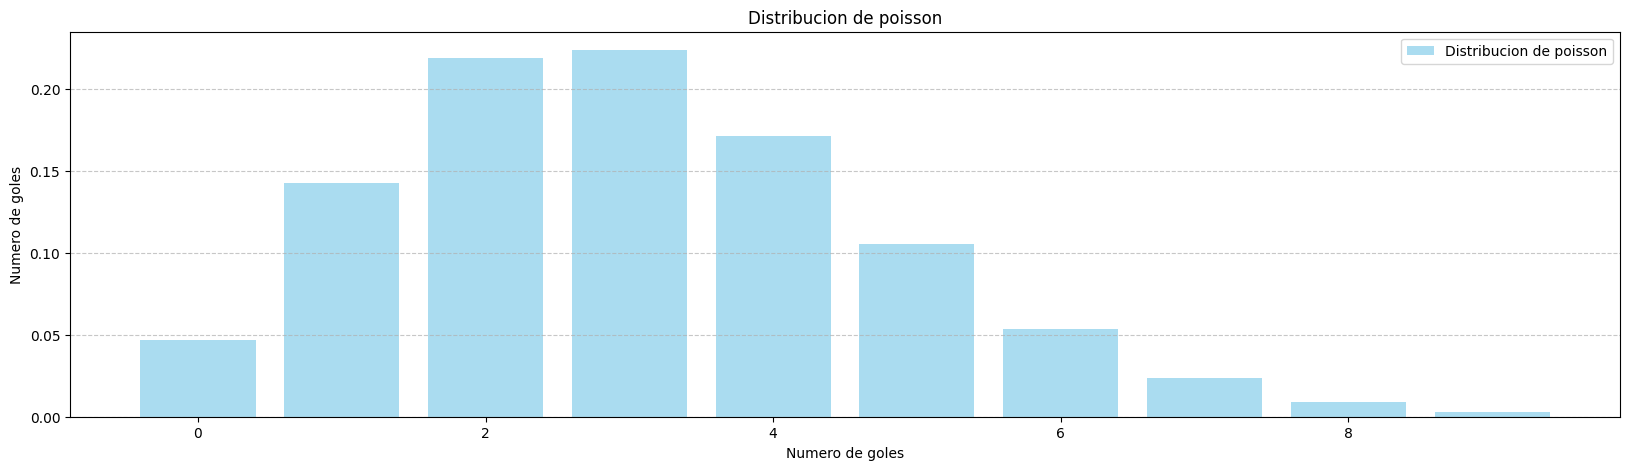

In [54]:
lambda_poisson = np.mean(goles)
x = np.arange(0, max(goles) + 1)
probabilidades = poisson.pmf(x, lambda_poisson)

fig, ax = plt.subplots(figsize=(20,5))
ax.bar(x, probabilidades, color='skyblue', alpha=0.7,label='Distribucion de poisson' )
ax.set_xlabel('Numero de goles')
ax.set_ylabel('Numero de goles')
ax.set_title(f'Distribucion de poisson')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)